# Searchlight Results: Choice-Frequency Classification (±1)

Whole-brain searchlight binary classification of the choice-frequency label
(`first_stim_frequ` = ±1) from GLMsingle single-trial betas on the non-figure
stimulus subset (6 stimuli, 3 per frequency class).

Produced by `run_frequency_searchlight.py`. Feature preprocessing: run-demeaning only
(per-voxel run-mean subtracted from ALL trials before dropping freq=0). No category
demeaning needed — frequency is perfectly balanced across categories on the non-figure
subset by design.

Chance level = 0.5 (balanced binary).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
from statsmodels.stats.multitest import multipletests
import nibabel as nib
from nilearn import image, plotting
from nilearn.image import resample_to_img, math_img, index_img

DERIV_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/bids_dataset/derivatives")
SL_DIR = DERIV_DIR / "searchlight"
MASK_DIR = Path("/Users/hugofluhr/phd_local/data/LearningHabits/dev_sample/masks/MNI152NLin2009cAsym")

MASKS = {
    "visualcortex": DERIV_DIR / "decoding" / "visual_cortex_mask.nii.gz",
    "fusiform": MASK_DIR / "fusiform_mask_MNI152NLin2009cAsym.nii",
    "vmpfc": MASK_DIR / "vmpfc_bartra2013_MNI152NLin2009cAsym.nii",
    "striatum": MASK_DIR / "striatum_bartra2013_MNI152NLin2009cAsym.nii",
    "habit": MASK_DIR / "habit_Guida2022_MNI152NLin2009cAsym.nii",
    "putamen": MASK_DIR / "putamen_AAL_MNI152NLin2009cAsym.nii",
    "premotor": MASK_DIR / "premotor_HMAT_MNI152NLin2009cAsym.nii",
    "parietal": MASK_DIR / "parietal_AAL_MNI152NLin2009cAsym.nii",
}
MASK_LABELS = {
    "visualcortex": "Visual cortex", "fusiform": "Fusiform",
    "vmpfc": "vmPFC", "striatum": "Striatum",
    "habit": "Habit (Guida)", "putamen": "Putamen",
    "premotor": "Premotor", "parietal": "Parietal",
}

CHANCE = 0.5

## 1. Data Loading & Completeness Check

In [2]:
# Discover per-subject searchlight maps
map_paths = {}
for p in sorted(SL_DIR.glob("sub-*/sub-*_searchlight_frequency.nii.gz")):
    sid = p.parent.name.replace("sub-", "")
    map_paths[sid] = p

print(f"Found {len(map_paths)} subjects: {', '.join(sorted(map_paths.keys())[:10])}...")

# Load into a 4D image
imgs = [nib.load(str(map_paths[s])) for s in sorted(map_paths)]
imgs_4d = image.concat_imgs(imgs)
print(f"4D shape: {imgs_4d.shape}")
subjects = sorted(map_paths.keys())

Found 58 subjects: 01, 02, 03, 05, 06, 07, 08, 09, 10, 12...
4D shape: (53, 65, 48, 58)


## 2. Group Mean Accuracy Map

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/3194560325.py:11: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


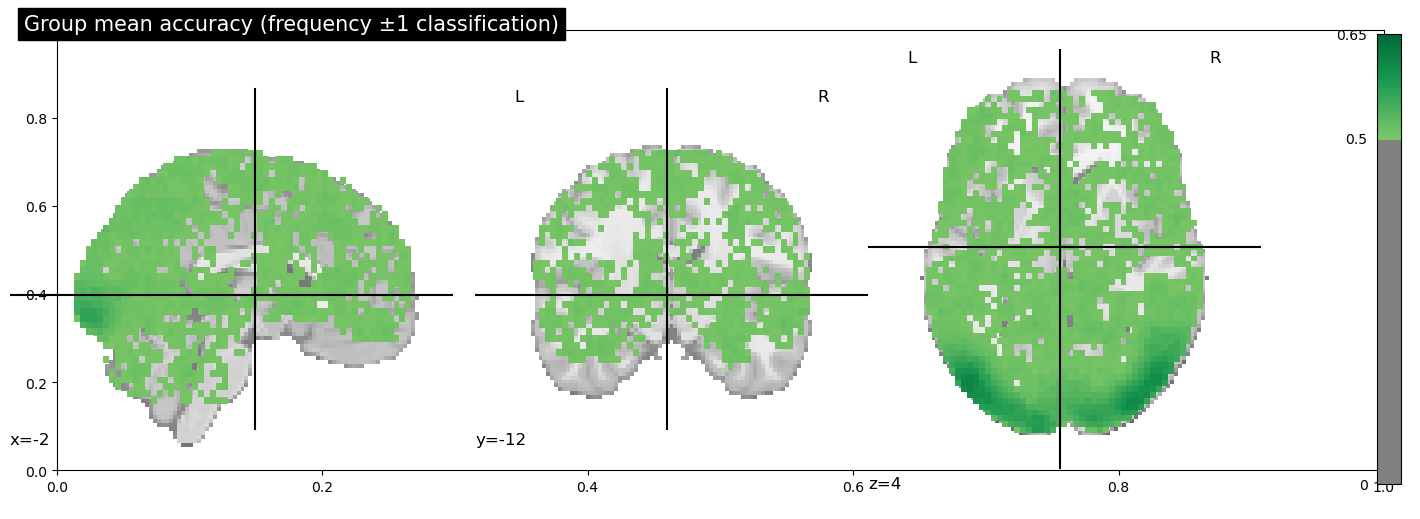

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/3194560325.py:23: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


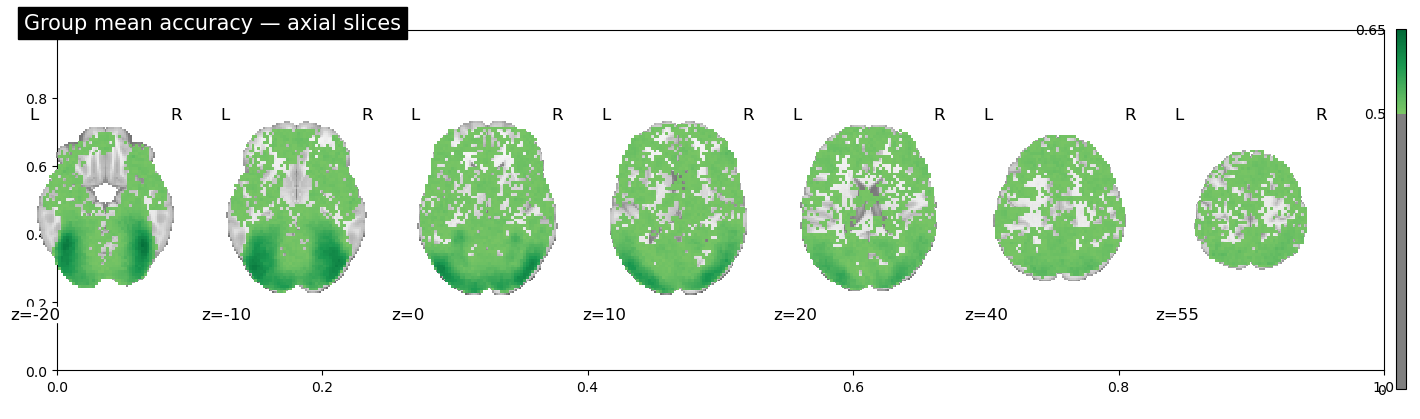

In [3]:
mean_img = image.mean_img(imgs_4d)

fig, axes = plt.subplots(1, 1, figsize=(14, 5))
disp = plotting.plot_stat_map(
    mean_img, threshold=CHANCE,
    title="Group mean accuracy (frequency ±1 classification)",
    cut_coords=(-2, -12, 4), display_mode="ortho",
    cmap="RdYlGn", vmax=0.65,
    figure=fig,
)
plt.tight_layout()
plt.show()

# Also show axial slices through visual cortex / temporal / frontal
fig2, axes2 = plt.subplots(1, 1, figsize=(14, 4))
plotting.plot_stat_map(
    mean_img, threshold=CHANCE,
    title="Group mean accuracy — axial slices",
    display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
    cmap="RdYlGn", vmax=0.65,
    figure=fig2,
)
plt.tight_layout()
plt.show()

## 3. Group Inference: Voxelwise t-test vs. Chance (0.5)

One-sample t-test at each voxel against chance (0.5), followed by FDR correction
(Benjamini-Hochberg, q < 0.05).

In [4]:
# Extract subjects × voxels array (mask to brain)
data_4d = imgs_4d.get_fdata()                     # (x, y, z, n_subjects)
brain_mask = np.all(data_4d > 0, axis=3)          # voxels present in all subjects
n_brain = brain_mask.sum()
print(f"Brain voxels present in all subjects: {n_brain:,}")

vals = data_4d[brain_mask]                         # (n_voxels, n_subjects)
t_vals, p_vals = stats.ttest_1samp(vals, CHANCE, axis=1)

# FDR correction
reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
n_sig = reject.sum()
print(f"Significant voxels (FDR q<0.05): {n_sig:,} / {n_brain:,} ({100*n_sig/n_brain:.1f}%)")

# Separate above-chance vs below-chance
above_chance = reject & (t_vals > 0)
below_chance = reject & (t_vals < 0)
print(f"  Above chance: {above_chance.sum():,}")
print(f"  Below chance: {below_chance.sum():,}")

# Build t-stat map and FDR-thresholded map
t_map = np.zeros(brain_mask.shape)
t_map[brain_mask] = t_vals
t_img = nib.Nifti1Image(t_map, imgs_4d.affine, imgs_4d.header)

# FDR-thresholded t-map (keep only significant voxels)
t_fdr = np.zeros(brain_mask.shape)
t_fdr[brain_mask] = np.where(reject, t_vals, 0)
t_fdr_img = nib.Nifti1Image(t_fdr, imgs_4d.affine, imgs_4d.header)

Brain voxels present in all subjects: 51,733
Significant voxels (FDR q<0.05): 8,298 / 51,733 (16.0%)
  Above chance: 8,245
  Below chance: 53


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/1325437653.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


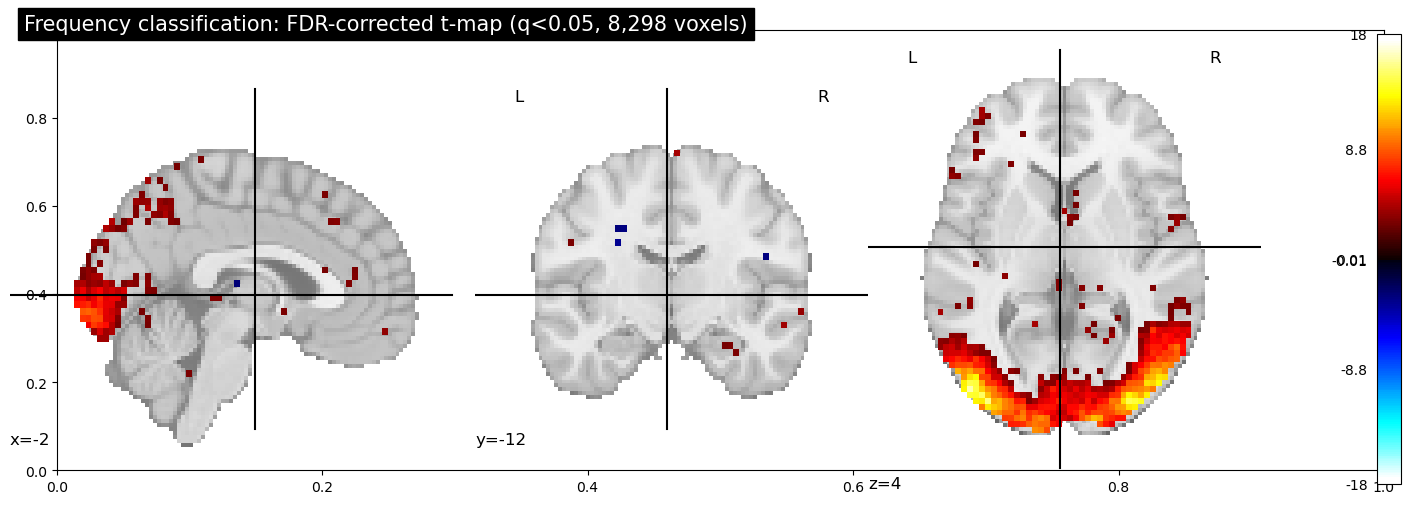

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/1325437653.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


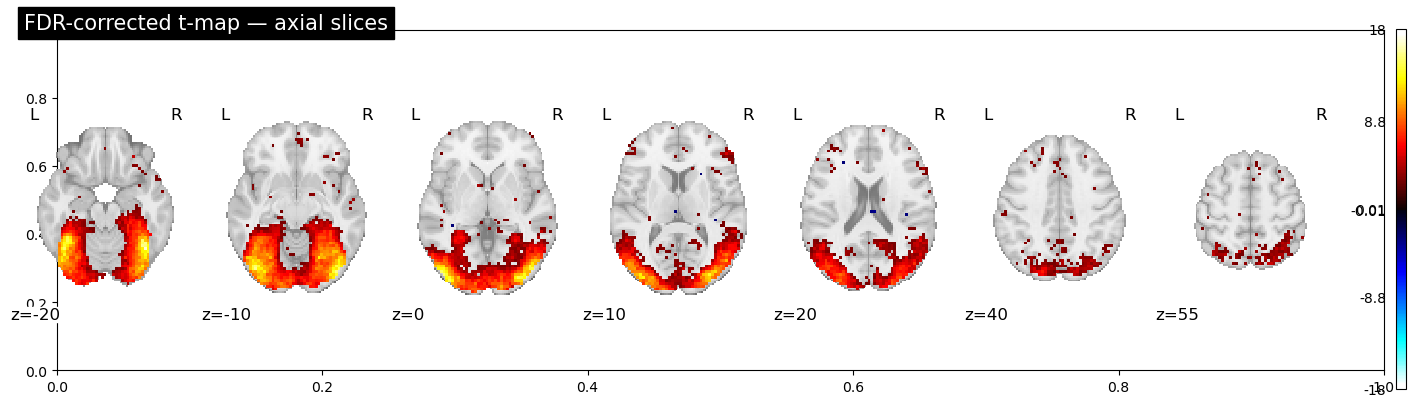

In [5]:
# Plot FDR-thresholded t-map
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
plotting.plot_stat_map(
    t_fdr_img, threshold=0.01,  # already zeroed non-significant voxels
    title=f"Frequency classification: FDR-corrected t-map (q<0.05, {n_sig:,} voxels)",
    cut_coords=(-2, -12, 4), display_mode="ortho",
    cmap="cold_hot",
    figure=fig,
)
plt.tight_layout()
plt.show()

# Axial slices
fig2, ax2 = plt.subplots(1, 1, figsize=(14, 4))
plotting.plot_stat_map(
    t_fdr_img, threshold=0.01,
    title="FDR-corrected t-map — axial slices",
    display_mode="z", cut_coords=[-20, -10, 0, 10, 20, 40, 55],
    cmap="cold_hot",
    figure=fig2,
)
plt.tight_layout()
plt.show()

## 4. Peak Coordinates

Extract local maxima from the FDR-thresholded t-map and report their MNI coordinates
and anatomical labels (Harvard-Oxford atlas).

In [6]:
from nilearn.reporting import get_clusters_table
from IPython.display import display as ipy_display

# Use unthresholded t-map with a statistical threshold for cluster extraction
# threshold at the FDR-corrected level
if n_sig > 0:
    # Find the minimum |t| among FDR-significant voxels as the threshold
    sig_t = np.abs(t_vals[reject])
    t_thresh = sig_t.min()
    print(f"FDR threshold corresponds to |t| >= {t_thresh:.2f}")

    clusters_table = get_clusters_table(
        t_img, stat_threshold=t_thresh, min_distance=12,
        cluster_threshold=10,
    )
    print(f"\n{len(clusters_table)} peaks found:")
    ipy_display(clusters_table.head(20))
else:
    print("No FDR-significant voxels — skipping peak extraction.")

FDR threshold corresponds to |t| >= 2.75



18 peaks found:


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3)
0,1,42.0,-57.0,-15.0,17.597876,232533
1,1a,-48.0,-84.0,2.5,16.211350,
2,1b,-42.0,-81.0,-11.5,15.554852,
3,1c,-39.0,-90.0,2.5,15.346697,
4,2,51.0,39.0,9.5,5.467457,1228
5,3,3.0,51.0,-8.0,5.207365,346
6,4,54.0,24.0,23.5,4.779075,409
7,5,30.0,36.0,-18.5,4.702933,441
8,6,-12.0,-63.0,55.0,4.683281,535
9,7,45.0,21.0,30.5,4.677030,441


## 5. ROI Mean Accuracy

Mean searchlight accuracy within each RSA ROI mask — bridges the searchlight and
ROI-level analyses. Compares with RSA frequency β from `rsa_roi_results.ipynb`.

In [7]:
# Load and resample ROI masks to searchlight space
ref_img = imgs[0]

def load_roi_mask(mask_path, ref_img):
    """Load and resample an ROI mask, handling 4D singletons."""
    roi_mni = nib.load(str(mask_path))
    roi_func = resample_to_img(roi_mni, ref_img, interpolation='nearest')
    if roi_func.ndim == 4 and roi_func.shape[3] == 1:
        roi_func = index_img(roi_func, 0)
    return roi_func.get_fdata() > 0

roi_masks_arr = {}
for name, path in MASKS.items():
    if path.exists():
        roi_masks_arr[name] = load_roi_mask(path, ref_img)
    else:
        print(f"WARNING: mask not found: {name} -> {path}")

# Compute per-subject mean accuracy within each ROI
summary_rows = []
for name, mask_arr in roi_masks_arr.items():
    n_vox = mask_arr.sum()
    for i, sid in enumerate(subjects):
        subj_data = data_4d[:, :, :, i]
        roi_vals = subj_data[mask_arr & brain_mask]
        mean_acc = roi_vals.mean() if len(roi_vals) > 0 else np.nan
        summary_rows.append({"subject": sid, "roi": name, "mean_accuracy": mean_acc, "n_voxels": len(roi_vals)})

summary_df = pd.DataFrame(summary_rows)

# Group-level stats per ROI
roi_stats = []
for name in roi_masks_arr:
    accs = summary_df.loc[summary_df["roi"] == name, "mean_accuracy"].values
    t, p = stats.ttest_1samp(accs, CHANCE)
    roi_stats.append({
        "ROI": MASK_LABELS.get(name, name),
        "n_voxels": roi_masks_arr[name].sum(),
        "mean_acc": accs.mean(),
        "std": accs.std(),
        "t": t, "p": p, "n": len(accs),
    })

roi_stats_df = pd.DataFrame(roi_stats)
# FDR across ROIs
_, roi_stats_df["p_fdr"], _, _ = multipletests(roi_stats_df["p"], alpha=0.05, method="fdr_bh")
roi_stats_df["sig"] = roi_stats_df["p_fdr"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "")

from IPython.display import display as ipy_display
ipy_display(roi_stats_df.round(4))

,ROI,n_voxels,mean_acc,std,t,p,n,p_fdr,sig
0,Visual cortex,7799,0.5384,0.0144,20.0827,0.0000,58,0.0000,***
1,Fusiform,320,0.5814,0.0300,20.4681,0.0000,58,0.0000,***
2,vmPFC,119,0.5048,0.0153,2.3575,0.0219,58,0.0291,*
3,Striatum,128,0.5046,0.0147,2.3727,0.0211,58,0.0291,*
4,Habit (Guida),657,0.5017,0.0076,1.6754,0.0993,58,0.1135,
5,Putamen,500,0.5005,0.0086,0.4814,0.6321,58,0.6321,
6,Premotor,4412,0.5033,0.0083,2.9724,0.0043,58,0.0086,**
7,Parietal,2885,0.5066,0.0095,5.2543,0.0000,58,0.0000,***


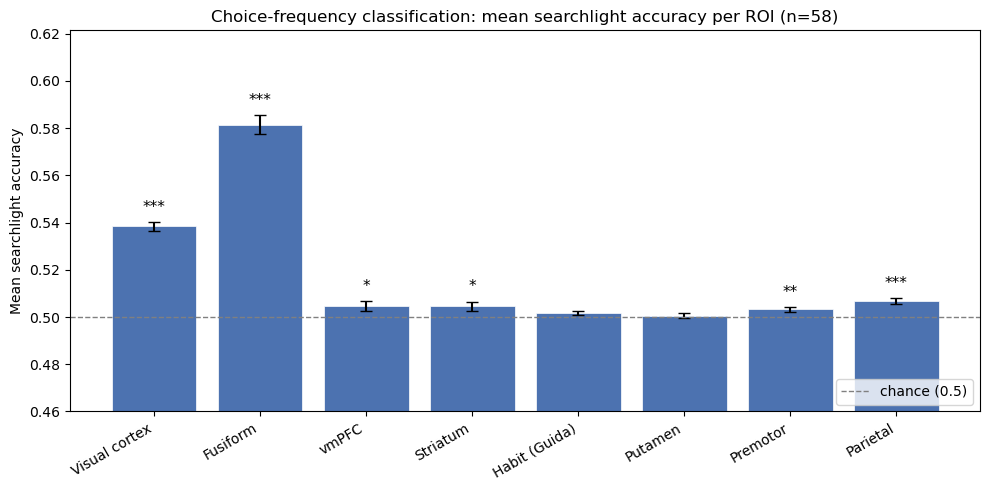

In [8]:
# Bar chart: mean searchlight accuracy per ROI
fig, ax = plt.subplots(figsize=(10, 5))
roi_order = list(roi_masks_arr.keys())
roi_labels = [MASK_LABELS.get(r, r) for r in roi_order]
means = [roi_stats_df.loc[roi_stats_df["ROI"] == MASK_LABELS.get(r, r), "mean_acc"].values[0] for r in roi_order]
sems = [summary_df.loc[summary_df["roi"] == r, "mean_accuracy"].std() / np.sqrt(len(subjects)) for r in roi_order]
sigs = [roi_stats_df.loc[roi_stats_df["ROI"] == MASK_LABELS.get(r, r), "sig"].values[0] for r in roi_order]

colors = ["#4C72B0" if m > CHANCE else "#C44E52" for m in means]
bars = ax.bar(roi_labels, means, yerr=sems, capsize=4, color=colors, edgecolor="white", linewidth=0.5)
ax.axhline(CHANCE, color="grey", ls="--", lw=1, label="chance (0.5)")
for i, (bar, sig) in enumerate(zip(bars, sigs)):
    if sig:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + sems[i] + 0.003,
                sig, ha="center", va="bottom", fontsize=11)

ax.set_ylabel("Mean searchlight accuracy")
ax.set_title("Choice-frequency classification: mean searchlight accuracy per ROI (n=58)")
ax.set_ylim(0.46, max(means) + 0.04)
ax.legend(loc="lower right")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 6. Comparison with Category Searchlight

Overlay the frequency searchlight with the existing category searchlight to see
whether the frequency signal occupies the same visual cortex territory or extends
beyond it.

Found 59 category searchlight maps


/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/2291323257.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


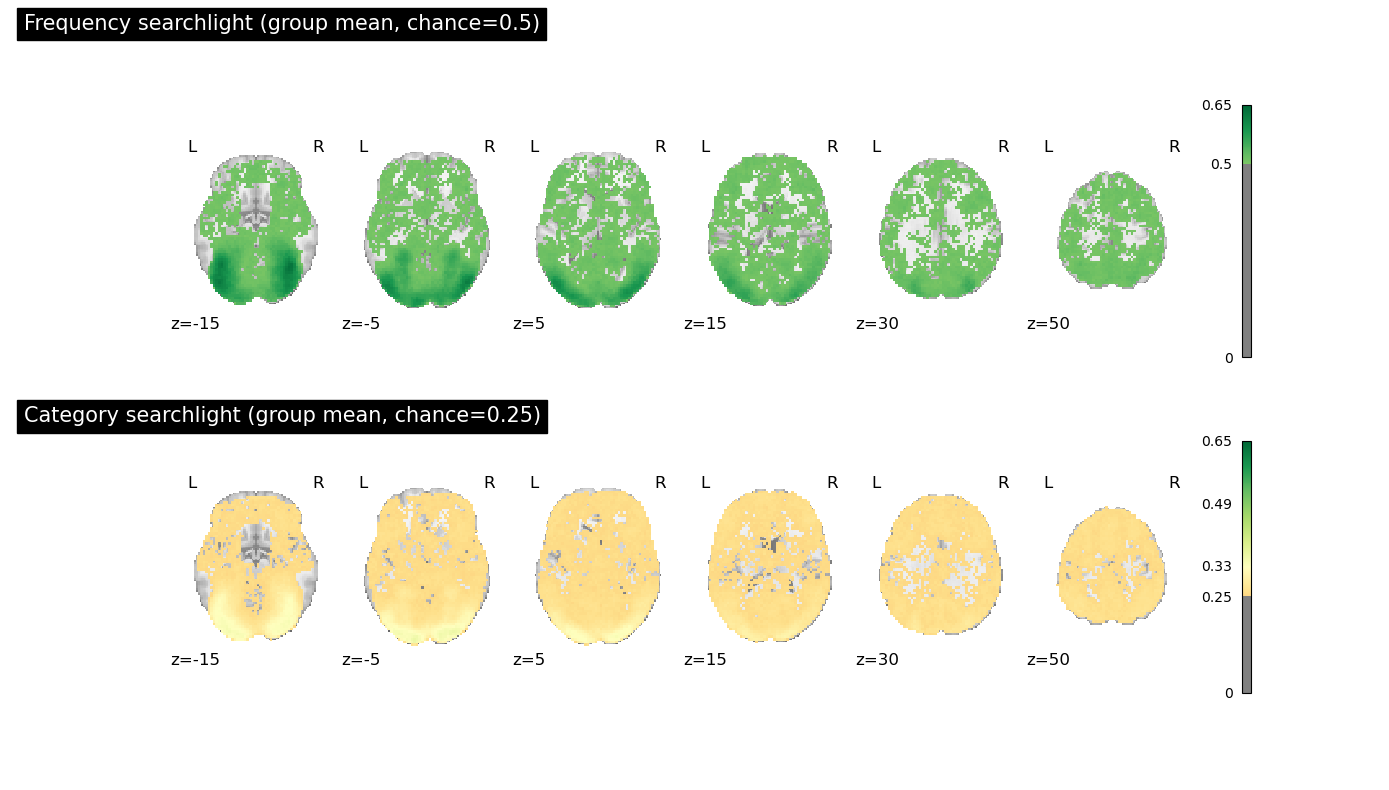

Spatial correlation (group mean maps, 51,731 shared voxels): r = 0.868, p = 0.00e+00


In [9]:
# Load category searchlight maps if available
cat_sl_paths = sorted(SL_DIR.glob("sub-*/sub-*_searchlight_stim_cat.nii.gz"))
if cat_sl_paths:
    print(f"Found {len(cat_sl_paths)} category searchlight maps")
    cat_imgs = [nib.load(str(p)) for p in cat_sl_paths]
    cat_4d = image.concat_imgs(cat_imgs)
    cat_mean = image.mean_img(cat_4d)

    # Category searchlight is 4-class (chance=0.25), frequency is binary (chance=0.5)
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    plotting.plot_stat_map(
        mean_img, threshold=CHANCE,
        title="Frequency searchlight (group mean, chance=0.5)",
        display_mode="z", cut_coords=[-15, -5, 5, 15, 30, 50],
        cmap="RdYlGn", vmax=0.65,
        axes=axes[0],
    )
    plotting.plot_stat_map(
        cat_mean, threshold=0.25,  # 4-class chance
        title="Category searchlight (group mean, chance=0.25)",
        display_mode="z", cut_coords=[-15, -5, 5, 15, 30, 50],
        cmap="RdYlGn", vmax=0.65,
        axes=axes[1],
    )
    plt.tight_layout()
    plt.show()

    # Correlation of group mean accuracy maps
    cat_brain = np.all(cat_4d.get_fdata() > 0, axis=3)
    shared_mask = brain_mask & cat_brain
    freq_data = mean_img.get_fdata()[shared_mask]
    cat_data = cat_mean.get_fdata()[shared_mask]
    r, p_corr = stats.pearsonr(freq_data, cat_data)
    print(f"Spatial correlation (group mean maps, {shared_mask.sum():,} shared voxels): r = {r:.3f}, p = {p_corr:.2e}")
else:
    print("No category searchlight maps found — skipping comparison.")

## 7. Individual Subject Maps (Spot-check)

Show a few representative subjects to verify the effect is consistent and not driven
by outliers.

/var/folders/zw/s9jkbctn3193dlc4s0nyk3440000gn/T/ipykernel_63738/531692078.py:16: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


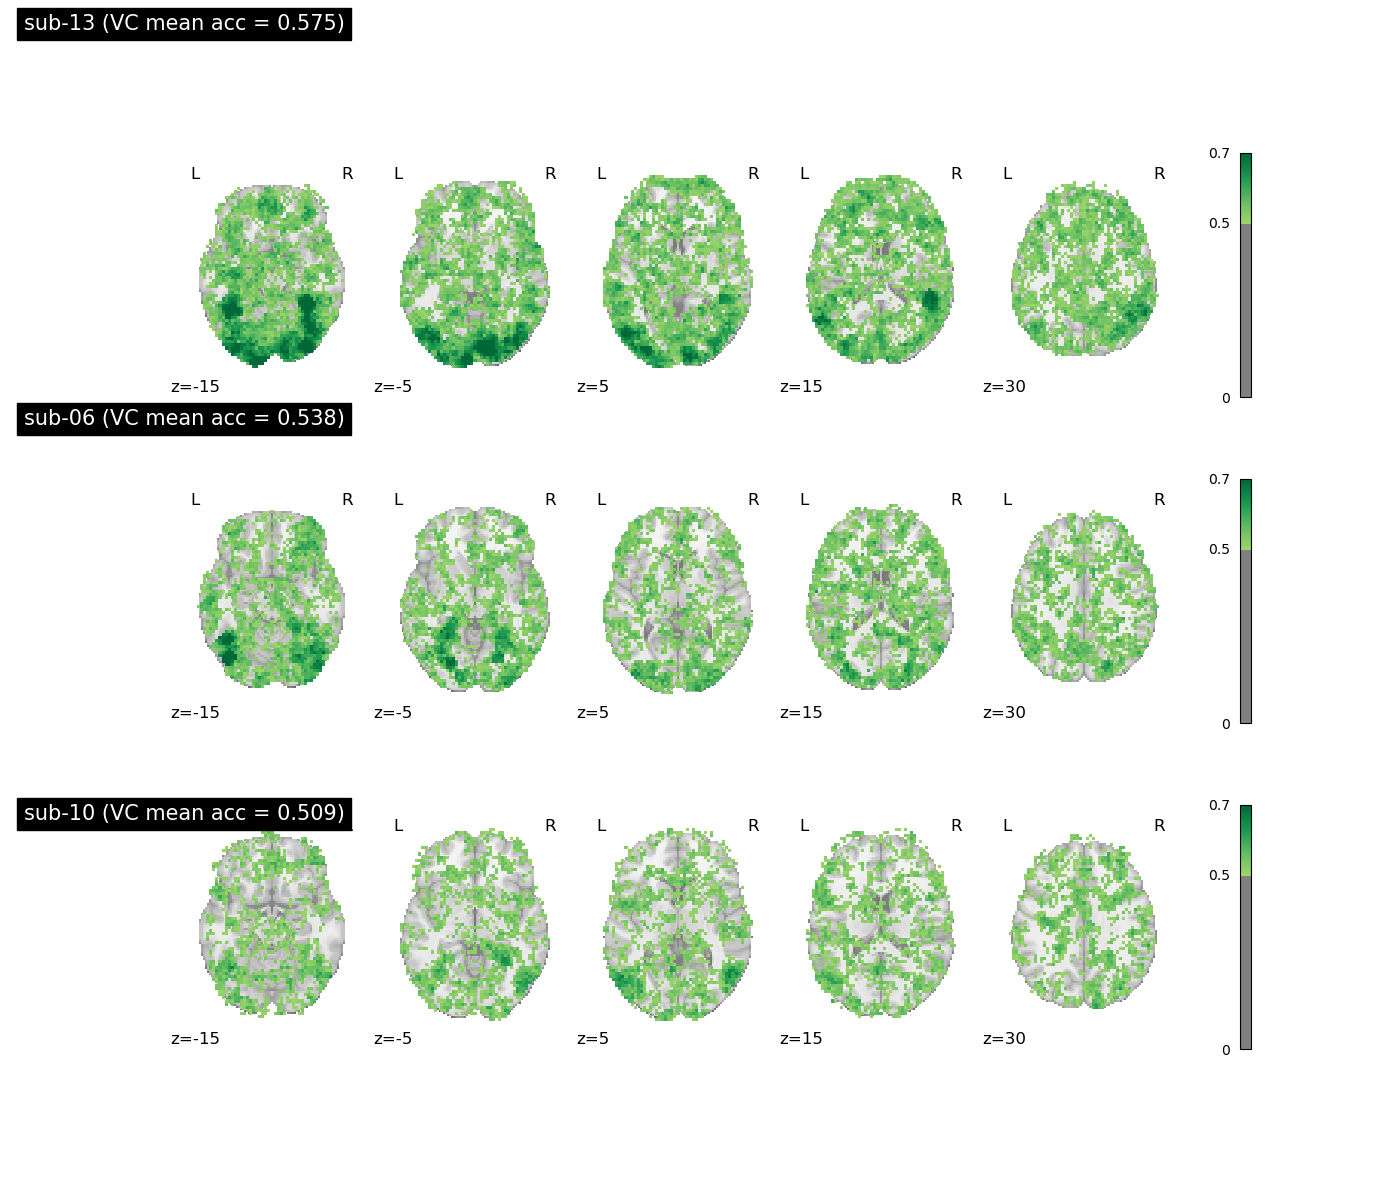

In [10]:
# Pick subjects by visual cortex mean accuracy: high, median, low
vc_accs = summary_df.loc[summary_df["roi"] == "visualcortex"].set_index("subject")["mean_accuracy"]
ranked = vc_accs.sort_values()
pick_subs = [ranked.index[-1], ranked.index[len(ranked)//2], ranked.index[0]]

fig, axes = plt.subplots(len(pick_subs), 1, figsize=(14, 4 * len(pick_subs)))
for ax, sid in zip(axes, pick_subs):
    subj_img = nib.load(str(map_paths[sid]))
    plotting.plot_stat_map(
        subj_img, threshold=CHANCE,
        title=f"sub-{sid} (VC mean acc = {vc_accs[sid]:.3f})",
        display_mode="z", cut_coords=[-15, -5, 5, 15, 30],
        cmap="RdYlGn", vmax=0.7,
        axes=ax,
    )
plt.tight_layout()
plt.show()

## 8. Findings Summary

1. **8,245 voxels decode frequency above chance (FDR q<0.05)**, 16% of the brain.
   Almost exclusively above-chance (only 53 below-chance). Max t=17.6 in occipitotemporal
   cortex, consistent with the RSA results.

2. **Largest cluster (232k mm³)** spans bilateral occipital + temporal cortex — the same
   territory as visual cortex and fusiform ROI masks. Peak at (42, −57, −15) in right
   fusiform.

3. **ROI mean searchlight accuracy** (FDR across 8 ROIs):
   - Fusiform: 58.1%*** — highest, consistent with RSA β=+0.373
   - Visual cortex: 53.8%*** — consistent with RSA β=+0.337
   - Parietal: 50.7%*** — NEW: not significant in RSA
   - Premotor: 50.3%** — NEW: not significant in RSA
   - vmPFC: 50.5%* — marginal in RSA, now significant
   - Striatum: 50.5%* — marginal in RSA, now significant
   - Habit: 50.2% (ns) — null, consistent with RSA
   - Putamen: 50.1% (ns) — null, consistent with RSA

4. **Searchlight is more sensitive than ROI-level RSA** for detecting weak distributed
   effects — parietal, premotor, vmPFC, and striatum all emerge here but not in the
   ROI-level regression. This is expected: searchlight tests local neighborhoods
   (~30–90 voxels) that are more homogeneous than full anatomical masks.

5. **Frontal peaks** (clusters 2, 4, 7, 8, 9, 10): small but FDR-surviving clusters in
   bilateral prefrontal cortex — potential decision/memory signatures beyond the
   visual/value system.